# Pattern 5 — Evaluator–Optimizer

## The idea in one line
**One LLM generates, another grades it. If it fails, feed the feedback back and try again.**

## When to use it
When you have a **clear success criterion** but one shot isn't good enough:

- "The joke should be funny" → a grader judges funny/not-funny
- "The SQL should return the right columns" → a grader runs and checks it
- "The translation should preserve tone" → a grader compares against the original

This is the pattern behind self-refining systems and LLM-as-judge loops.

## When *not* to use it
If the first output is usually fine, don't add a loop — it just burns tokens and latency. Use it when retries genuinely help.

## The shape of the graph

![Evaluator–optimizer workflow](../images/evaluator_optimizer.avif)


```
START ─► generator ─► evaluator ──(funny)──► END
               ▲               │
               │               └──(not funny + feedback)──┐
               └────────────────────────────────────────── ┘
```

The **generator** reads any feedback from the previous round and uses it in the next prompt. The **evaluator** returns a structured grade + feedback.


In [1]:
# Setup — run this first in every notebook
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=1.0,
    max_retries=2,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)


## Example 1 — The docs example (joke quality loop)

Generator writes a joke. Evaluator decides `funny` or `not funny` and gives improvement feedback. If not funny, loop back.


In [2]:
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(description="Decide if the joke is funny or not.")
    feedback: str = Field(description="If not funny, provide feedback on how to improve it.")


evaluator = llm.with_structured_output(Feedback)


def llm_call_generator(state: State):
    """Generate a joke (using feedback from the previous round, if any)."""
    if state.get("feedback"):
        msg = llm.invoke(f"Write a joke about {state['topic']} but consider: {state['feedback']}")
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """Grade the joke."""
    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


def route_joke(state: State):
    if state["funny_or_not"] == "funny":
        return "Accepted"
    return "Rejected + Feedback"


optimizer_builder = StateGraph(State)
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

graph = optimizer_builder.compile()


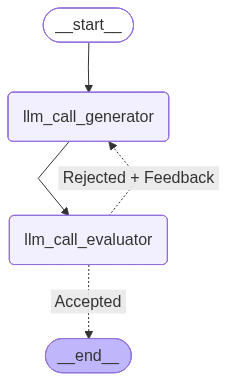

In [3]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
state = graph.invoke({"topic": "Cats"})
print("Final joke:")
print(state["joke"])
print()
print("Verdict:", state["funny_or_not"])
print("Evaluator feedback:", state["feedback"])


Final joke:
[{'type': 'text', 'text': 'A guy is walking through a neighborhood and sees a sign in a yard: **"Talking Cat for Sale - $10."**\n\nIntrigued, he rings the doorbell. The owner tells him the cat is out in the backyard. The guy walks into the backyard and sees a black cat sitting on a lawn chair.\n\n"You talk?" the man asks, skeptical.\n\n"Yep," the cat replies casually.\n\nThe man is stunned. "So, what\'s your story?"\n\nThe cat looks up and says, "Well, I discovered I could talk when I was just a kitten. I wanted to help the government, so I told the CIA. In no time at all, they had me jetting from country to country, sitting in rooms with spies and world leaders, because no one ever suspects a cat would be eavesdropping. I was their most valuable secret agent for eight years. But the travel tired me out, so I settled down and took a job at the airport doing undercover security, wandering near suspicious characters and listening in. I got married, had a few litters of kitten

## Example 2 — Real use case: tweet polisher with quality bar

A grader checks whether a tweet is **hooky** (starts strong, under 280 chars, has a clear single idea). If not, it explains why and the generator tries again.

We also add a **max retries** guard — a very common real-world addition, since an LLM-as-judge could loop forever if it's too strict.


In [5]:
class TweetGrade(BaseModel):
    verdict: Literal["good", "weak"] = Field(description="'good' if the tweet meets all criteria, else 'weak'.")
    feedback: str = Field(description="If weak, explain specifically what to improve.")


tweet_judge = llm.with_structured_output(TweetGrade)


class TweetState(TypedDict):
    idea: str
    tweet: str
    verdict: str
    feedback: str
    attempts: int


def write_tweet(state: TweetState):
    prompt = (
        "Write a single tweet (under 280 chars, no hashtags, no emojis unless it really helps). "
        f"Idea: {state['idea']}."
    )
    if state.get("feedback"):
        prompt += f"\n\nPrevious attempt feedback: {state['feedback']}. Fix that."
    msg = llm.invoke(prompt)
    return {"tweet": msg.content, "attempts": state.get("attempts", 0) + 1}


def judge_tweet(state: TweetState):
    grade = tweet_judge.invoke(
        "Judge this tweet on three criteria: strong opening hook, under 280 chars, one clear single idea. "
        f"Tweet: {state['tweet']}"
    )
    return {"verdict": grade.verdict, "feedback": grade.feedback}


def decide(state: TweetState):
    # Accept if good, OR give up after 3 attempts (avoid infinite loops)
    if state["verdict"] == "good" or state["attempts"] >= 3:
        return "done"
    return "retry"


tweet_wf = StateGraph(TweetState)
tweet_wf.add_node("write_tweet", write_tweet)
tweet_wf.add_node("judge_tweet", judge_tweet)

tweet_wf.add_edge(START, "write_tweet")
tweet_wf.add_edge("write_tweet", "judge_tweet")
tweet_wf.add_conditional_edges("judge_tweet", decide, {"done": END, "retry": "write_tweet"})

graph = tweet_wf.compile()


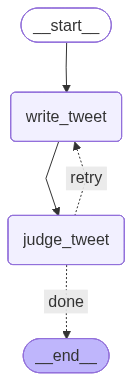

In [6]:
# Visualize the graph (renders as an image in Jupyter)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
out = graph.invoke({"idea": "LangGraph makes multi-step LLM apps feel like normal Python"})

print(f"Final tweet (after {out['attempts']} attempt(s), verdict={out['verdict']}):")
print(out["tweet"])
print()
print("Last feedback:", out["feedback"])


Final tweet (after 1 attempt(s), verdict=good):
[{'type': 'text', 'text': 'LangGraph makes building complex, multi-step LLM apps feel like writing normal Python. Instead of fighting a framework to handle cycles or shared state, you just define your logic as a graph. It’s the best way to get granular control over agentic workflows.', 'extras': {'signature': 'EqwRCqkRAQw51sfThv3qBAxpDJDGfb+HFShifHDANckItvryDaklV0Ku1FF8j9gbkJxLAnzywpQ3aJVweRzLgJBe8Mhi8HnJmQmlLLLJ6VGnEymb27Jyu5P8ZRVR3uiKskfNm4JU1IHjZA0iaoOQPA3SD9bD0IZXgViFOzPWoIC1U1IkP9q4vr3M/mX7KF//LlzpZ64gVl+2KwIYnszFRk1B2d3rEFkhBQ3GEHUiIY789uRHDg9ZXcqzR25I8wQ+TyDlhkqIQzkFPPvLmcdwtvShvqZzgSknT4fuurVJydctwfKZPUUyRPq1uB8fn4hlJQChltYth/HPQhxwWWNBhIl2gFm5nDloJsECBcdIFKb8wgpvqxn6xrJVtfZOlru7t/gchBM+5T6TXr9ZxCxKJYrKrY+5EL+SJ0zLYSO3XhCzZkTNX8iODamPtbHcZ8FwM5UiUY4gZs5oc7V2YSG8ZgrW7Vb5uSnakUOkOr4bmYU2MlwFrHIwfd7tOGzDy0lH0Z1lvcg3LJILmnT2VwDB4OnDJUDWEwCPG/PUeEG/Q+Ze3MOyMvE2PPJC60J0E2dvInMcs48HoY09EEWoLCuON1ZBd37ljGhc4TiPMLdGFpci+kG0punLV439fKxvWa5v

## Takeaways

- Two LLM roles: **generator** + **evaluator** (a.k.a. LLM-as-judge).
- The loop ends when the evaluator says "good enough" (or when you hit a safety cap on retries).
- Works best when the criteria are **specific and checkable** — vague criteria = bad grader.
- Always add a **max-retries** guard in production.

## Try it yourself

- Replace the joke example with: generator writes a SQL query from a natural-language request; evaluator checks that the query is syntactically valid (you can use `sqlparse`) and loops back with the parser's error message as feedback.
